<a href="https://colab.research.google.com/github/lzhkaya98/SSM-Differential-Retrieval/blob/main/RZSMretrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
tensor(0.0245, grad_fn=<MeanBackward0>)
R2=0.7359517812728882
bias=0.001290598651394248
RMSE=0.03497692570090294
ubRMSE=0.03495310619473457
R P PearsonRResult(statistic=np.float64(0.8581073295875439), pvalue=np.float32(0.0))


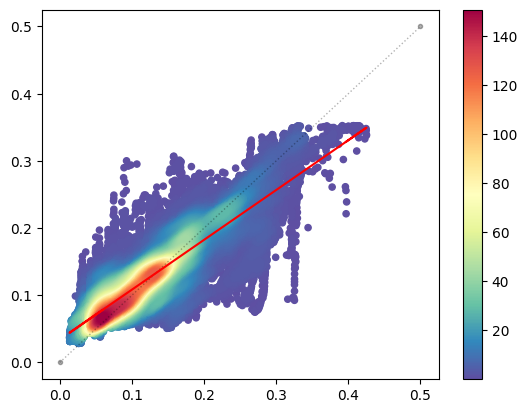

In [ ]:
#!pip install torch

import torch
import torch.nn as nn
import torch.nn.functional as tf
from torch.utils import data
import numpy as np
import xlrd
import random
from sklearn import preprocessing
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pylab

from google.colab import drive
drive.mount('/content/drive')

#数据集加载
def load_data(StartPo,EndPo,TestProportion,FeatureNum,Shuffle,FilePath):         #样本起始行数，结束行数，测试集占总样本集比重,特征数，是否打乱样本集     #如果Testproportion为0或1就训练集=测试集
    #打开excel文件
    workbook = xlrd.open_workbook(str(FilePath))       #excel路径
    sheet = workbook.sheet_by_name('sheet1')             #sheet表
    Sample = []#总样本集
    train = []#训练集
    test = []#测试集
    TestSetSphere = (EndPo-StartPo+1)*TestProportion  #测试集数目
    TestSetSphere = int(TestSetSphere)#测试集数目
    #获取全部样本集并打乱顺序
    for loadi in range(StartPo-1,EndPo):
        RowSample = sheet.row_values(loadi)
        Sample.append(RowSample)
    if Shuffle == 1:  #是否打乱样本集
        random.shuffle(Sample)  #如果shuffle=1，打乱样本集
    #如果Testproportion为0就训练集=测试集
    if TestProportion == 0 or TestProportion == 1:
        TrainSet = np.array(Sample)          #变换为array
        TestSet = np.array(Sample)
        TrainSet = torch.Tensor(TrainSet)
        TestSet = torch.Tensor(TestSet)
    else:
        #设置训练集
        for loadtraina in Sample[:(EndPo-TestSetSphere)]:
            GetTrainValue = loadtraina
            train.append(GetTrainValue)
        #设置测试集
        for loadtesta in range(-TestSetSphere-1,-1):
            GetTestValue = Sample[loadtesta]
            test.append(GetTestValue)
        #变换样本集
        TrainSet = np.array(train)                  #变换为array
        TestSet = np.array(test)
        TrainSet = torch.Tensor(TrainSet)
        TestSet = torch.Tensor(TestSet)


   #分割特征与目标变量
    x1 , y1 = TrainSet[:,:FeatureNum] , TrainSet[:,-1]
    SSM_train = x1[:,0] ; SSM_ave_train = x1[:,1] ; veg_train = x1[:,2:8] ; B_train = x1[:,8:11] ; PET_train = x1[:,11] ; SWI_train = x1[:,12]
    x2 , y2 = TestSet[:,:FeatureNum] , TestSet[:,-1]
    SSM_test = x2[:,0]; SSM_ave_test = x2[:,1] ; veg_test = x2[:, 2:8]; B_test = x2[:,8:11]; PET_test = x2[:, 11]; SWI_test = x2[:,12]
    return torch.unsqueeze(SSM_train,dim=1), torch.unsqueeze(SSM_ave_train,dim=1), veg_train, B_train, torch.unsqueeze(PET_train,dim=1), torch.unsqueeze(SWI_train,dim=1), torch.unsqueeze(y1,dim=1) , torch.unsqueeze(SSM_test,dim=1), torch.unsqueeze(SSM_ave_test,dim=1), veg_test, B_test, torch.unsqueeze(PET_test,dim=1), torch.unsqueeze(SWI_test,dim=1), torch.unsqueeze(y2,dim=1)

SSM_train , SSM_ave_train, veg_train, B_train, PET_train, SWI_train, y1 , SSM_test, SSM_ave_test, veg_test, B_test, PET_test, SWI_test, y2 = load_data(2,41587,0,13,1,str('/content/drive/My Drive/train_RZSM.xls'))
#网络超参数设置
#具有两个隐藏层的FNN
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size,hidden_size)
        self.fc4 = nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

class Net2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net2, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size,hidden_size)
        self.fc4 = nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        x = torch.tanh(x) * 5 + 55
        return x
#调用模型
#model = Net(input_size, hidden_size, output_size)
#损失和优化器
#criterion = nn.MSELoss()
#trainer = torch.optim.SGD(model.parameters(), lr=0.01)

def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=True)

#微分蒸发效率方程 饱和水含量0.6
def be_ta(Bi, PETi, SSMi):
    P = PETi / (2 *Bi)
    gamma = 0.5 - 0.5 * torch.cos(torch.pi * SSMi / 0.6)
    output = torch.pow(gamma, P)
    return output

#散点图
def scatter_plot_frequency(x, y):
  xy = np.vstack([x,y])
  z = gaussian_kde(xy)(xy)
  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]
  fig, ax = plt.subplots()
  # 设置参考的1：1虚线参数
  xxx = [0, 0.5]  #[0, 0.6] 40
  yyy = [0, 0.5]
  plt.plot(xxx, yyy, c='0', linewidth=1, linestyle=':', marker='.', alpha=0.3)  # 绘制虚线
  plt.scatter(x, y, c=z, s=20, cmap='Spectral_r')
  z=np.polyfit(x,y,1)
  p=np.poly1d(z)
  pylab.plot(x,p(x),"r")
  plt.colorbar()
  plt.show()

#模型训练
batch_size = 64 #16,32,64,128...
num_epochs = 5000  #50,100,150...1000
data_iter = load_array((SSM_train , SSM_ave_train, veg_train, B_train, PET_train, SWI_train, y1), batch_size)

model_B = Net2(3,5,1)
model_VC = Net(6,10,1)
model_SM = Net(5,10,1)
#定义损失函数和优化器
criterion = nn.L1Loss()
trainer1 = torch.optim.SGD(model_SM.parameters(),lr=0.01)
trainer2 = torch.optim.SGD(model_VC.parameters(),lr=0.01)
trainer3 = torch.optim.SGD(model_B.parameters(),lr=0.01)

for epoch in range(num_epochs):
    for SSM,SSM_ave,veg,B,PET,SWI,y in data_iter:
        VC = model_VC(veg)
        B1 = model_B(B)
        Beta = be_ta(B1, PET, SSM)
        input = torch.cat([SSM,SSM_ave,Beta,VC,SWI], dim=1)
        SM = model_SM(input)

        loss = criterion(SM, y)
        #print(loss)
        model_SM.zero_grad()
        model_VC.zero_grad()
        model_B.zero_grad()
        loss.backward()
        trainer1.step()
        trainer2.step()
        trainer3.step()
#    print(f'epoch {epoch+1}')

#模型保存
#torch.save(model_B.state_dict(), str('/content/drive/My Drive/model_B_RZSM.pth'))
#torch.save(model_VC.state_dict(), str('/content/drive/My Drive/model_VC_RZSM.pth'))
#torch.save(model_SM.state_dict(), str('/content/drive/My Drive/model_SM_RZSM.pth'))

#模型加载 需实例化模型
#model_C.load_state_dict(torch.load(str('/content/drive/My Drive/model_C.pth')))
#model_VC.load_state_dict(torch.load(str('/content/drive/My Drive/model_VC.pth')))
#model_SM.load_state_dict(torch.load(str('/content/drive/My Drive/model_SM.pth')))
#model_C.eval();model_VC.eval();model_SM.eval()

#模型测试
VC_test = model_VC(veg_test)
B1_test = model_B(B_test)
Beta_test = be_ta(B1_test, PET_test, SSM_test)
input_test = torch.cat([SSM_test,SSM_ave_test,Beta_test,VC_test,SWI_test], dim=1)
SM_test = model_SM(input_test)
loss = criterion(SM_test, y2)
print(loss)

#模型输出评估
#"""
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

Y_test = y2.numpy()
Y_pred = SM_test.detach().numpy()
#print(Y_test)
#print(Y_pred)
r2 = r2_score(Y_test, Y_pred)
ResidualSquare = (Y_pred - Y_test) ** 2
MSE = np.mean(ResidualSquare)
bias = np.mean(Y_pred - Y_test)
RMSE = np.sqrt(MSE)
ubRMSE = np.sqrt(RMSE ** 2 - bias ** 2)
print(f'R2={r2}')
print(f'bias={bias}')
print(f'RMSE={RMSE}')
print(f'ubRMSE={ubRMSE}')
print("R P", pearsonr(Y_pred[:,0], Y_test[:,0]))
scatter_plot_frequency(Y_test[:,0],Y_pred[:,0])  #生成散点图
#"""

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
R2=0.657253623008728
bias=0.003771008923649788
RMSE=0.025855587795376778
ubRMSE=0.025579111650586128
R P PearsonRResult(statistic=np.float64(0.8234374703770232), pvalue=np.float32(0.0))


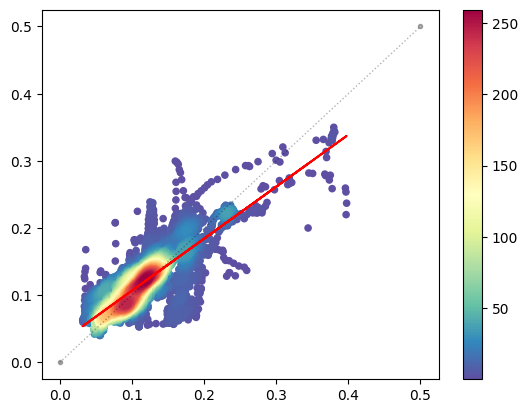

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as tf
from torch.utils import data
import numpy as np
import xlrd
import random
from sklearn import preprocessing
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pylab

from google.colab import drive
drive.mount('/content/drive')

#数据集加载
def load_data(StartPo,EndPo,TestProportion,FeatureNum,Shuffle,FilePath):         #样本起始行数，结束行数，测试集占总样本集比重,特征数，是否打乱样本集     #如果Testproportion为0或1就训练集=测试集
    #打开excel文件
    workbook = xlrd.open_workbook(str(FilePath))       #excel路径
    sheet = workbook.sheet_by_name('sheet1')             #sheet表
    Sample = []#总样本集
    train = []#训练集
    test = []#测试集
    TestSetSphere = (EndPo-StartPo+1)*TestProportion  #测试集数目
    TestSetSphere = int(TestSetSphere)#测试集数目
    #获取全部样本集并打乱顺序
    for loadi in range(StartPo-1,EndPo):
        RowSample = sheet.row_values(loadi)
        Sample.append(RowSample)
    if Shuffle == 1:  #是否打乱样本集
        random.shuffle(Sample)  #如果shuffle=1，打乱样本集
    #如果Testproportion为0就训练集=测试集
    if TestProportion == 0 or TestProportion == 1:
        TrainSet = np.array(Sample)          #变换为array
        TestSet = np.array(Sample)
        TrainSet = torch.Tensor(TrainSet)
        TestSet = torch.Tensor(TestSet)
    else:
        #设置训练集
        for loadtraina in Sample[:(EndPo-TestSetSphere)]:
            GetTrainValue = loadtraina
            train.append(GetTrainValue)
        #设置测试集
        for loadtesta in range(-TestSetSphere-1,-1):
            GetTestValue = Sample[loadtesta]
            test.append(GetTestValue)
        #变换样本集
        TrainSet = np.array(train)                  #变换为array
        TestSet = np.array(test)
        TrainSet = torch.Tensor(TrainSet)
        TestSet = torch.Tensor(TestSet)


   #分割特征与目标变量
    x1 , y1 = TrainSet[:,:FeatureNum] , TrainSet[:,-1]
    SSM_train = x1[:,0] ; SSM_ave_train = x1[:,1] ; veg_train = x1[:,2:8] ; B_train = x1[:,8:11] ; PET_train = x1[:,11] ; SWI_train = x1[:,12]
    x2 , y2 = TestSet[:,:FeatureNum] , TestSet[:,-1]
    SSM_test = x2[:,0]; SSM_ave_test = x2[:,1] ; veg_test = x2[:, 2:8]; B_test = x2[:,8:11]; PET_test = x2[:, 11]; SWI_test = x2[:,12]
    return torch.unsqueeze(SSM_train,dim=1), torch.unsqueeze(SSM_ave_train,dim=1), veg_train, B_train, torch.unsqueeze(PET_train,dim=1), torch.unsqueeze(SWI_train,dim=1), torch.unsqueeze(y1,dim=1) , torch.unsqueeze(SSM_test,dim=1), torch.unsqueeze(SSM_ave_test,dim=1), veg_test, B_test, torch.unsqueeze(PET_test,dim=1), torch.unsqueeze(SWI_test,dim=1), torch.unsqueeze(y2,dim=1)

SSM_train , SSM_ave_train, veg_train, B_train, PET_train, SWI_train, y1 , SSM_test, SSM_ave_test, veg_test, B_test, PET_test, SWI_test, y2 = load_data(2,41587,0.2,13,0,str('/content/drive/My Drive/train_RZSM.xls'))
#网络超参数设置
#具有两个隐藏层的FNN
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size,hidden_size)
        self.fc4 = nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

class Net2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net2, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size,hidden_size)
        self.fc4 = nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        x = torch.tanh(x) * 5 + 55
        return x
#调用模型
#model = Net(input_size, hidden_size, output_size)
#损失和优化器
#criterion = nn.MSELoss()
#trainer = torch.optim.SGD(model.parameters(), lr=0.01)

#微分蒸发效率方程 饱和水含量0.6
def be_ta(Bi, PETi, SSMi):
    P = PETi / (2 *Bi)
    gamma = 0.5 - 0.5 * torch.cos(torch.pi * SSMi / 0.6)
    output = torch.pow(gamma, P)
    return output

#散点图
def scatter_plot_frequency(x, y):
  xy = np.vstack([x,y])
  z = gaussian_kde(xy)(xy)
  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]
  fig, ax = plt.subplots()
  # 设置参考的1：1虚线参数
  xxx = [0, 0.5]  #[0, 0.6] 40
  yyy = [0, 0.5]
  plt.plot(xxx, yyy, c='0', linewidth=1, linestyle=':', marker='.', alpha=0.3)  # 绘制虚线
  plt.scatter(x, y, c=z, s=20, cmap='Spectral_r')
  z=np.polyfit(x,y,1)
  p=np.poly1d(z)
  pylab.plot(x,p(x),"r")
  plt.colorbar()
  plt.show()


model_B = Net2(3,5,1)
model_VC = Net(6,10,1)
model_SM = Net(5,10,1)

#模型加载 需实例化模型
model_B.load_state_dict(torch.load(str('/content/drive/My Drive/model_B_RZSM.pth')))
model_VC.load_state_dict(torch.load(str('/content/drive/My Drive/model_VC_RZSM.pth')))
model_SM.load_state_dict(torch.load(str('/content/drive/My Drive/model_SM_RZSM.pth')))
model_B.eval();model_VC.eval();model_SM.eval()

#模型测试
VC_test = model_VC(veg_test)
B1_test = model_B(B_test)
Beta_test = be_ta(B1_test, PET_test, SSM_test)
input_test = torch.cat([SSM_test,SSM_ave_test,Beta_test,VC_test,SWI_test], dim=1)
SM_test = model_SM(input_test)

#模型输出评估
#"""
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

Y_test = y2.numpy()
Y_pred = SM_test.detach().numpy()
#print(Y_test)
#print(Y_pred)
r2 = r2_score(Y_test, Y_pred)
ResidualSquare = (Y_pred - Y_test) ** 2
MSE = np.mean(ResidualSquare)
bias = np.mean(Y_pred - Y_test)
RMSE = np.sqrt(MSE)
ubRMSE = np.sqrt(RMSE ** 2 - bias ** 2)
print(f'R2={r2}')
print(f'bias={bias}')
print(f'RMSE={RMSE}')
print(f'ubRMSE={ubRMSE}')
print("R P", pearsonr(Y_pred[:,0], Y_test[:,0]))
scatter_plot_frequency(Y_test[:,0],Y_pred[:,0])  #生成散点图
#"""